In [55]:
import numpy as np
import matplotlib as mpl
mpl.rcParams['figure.dpi']=100
from skimage.io import imread
from skimage.transform import rescale
from skimage.color import rgb2lab, lab2rgb, rgb2gray
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import kagglehub

In [6]:
# Downloads latest version of dataset
path = kagglehub.dataset_download("shahzaibshazoo/detect-ai-generated-faces-high-quality-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Magnus\.cache\kagglehub\datasets\shahzaibshazoo\detect-ai-generated-faces-high-quality-dataset\versions\1


In [64]:
def preprocess_image(image_path, target_width=150):
    """
    Reads an image, handles channel inconsistencies, converts to grayscale if necessary, 
    rescales, and normalizes pixel values.
    """
    # Read the image
    image_raw = imread(image_path)
    
    # Handle channel inconsistencies
    if len(image_raw.shape) == 3:  # RGB or RGBA image
        if image_raw.shape[-1] == 4:  # RGBA (4 channels)
            image_raw = image_raw[..., :3]  # Drop the alpha channel
        image = rgb2gray(image_raw)  # Convert RGB to grayscale
    elif len(image_raw.shape) == 2:  # Already grayscale (2D array)
        image = image_raw / 255.0  # Normalize pixel values to [0, 1]
    else:
        raise ValueError(f"Unexpected image shape: {image_raw.shape}")

    # Rescale the grayscale image to the target size
    rescaled_image = rescale(image, target_width / image.shape[0], mode='reflect', anti_aliasing=True)

    return rescaled_image

# Define image paths
ai_path = path + r'\AI-face-detection-Dataset\AI\35_20241130140313_A_close-up_shot_of_a_young_adult_male_person_of_Na.jpg'
real_path = path + r'\AI-face-detection-Dataset\real\non-child-1085.png'

# Preprocess images
ai_image = preprocess_image(ai_path)
real_image = preprocess_image(real_path)

# Stack into a dataset (if you have more images, append them here)
dataset = np.stack([ai_image, real_image])  # Shape: (2, 150, 150)

# Labels for the images
labels = np.array([1, 0])  # Example: 1 for "child", 0 for "non-child"

# Print shapes
print("Dataset shape:", dataset.shape)
print("Labels shape:", labels.shape)

# Visualize one of the images
plt.figure()
plt.imshow(dataset[0], cmap='gray')
plt.axis('off')
plt.show()

ValueError: the input array must have size 3 along `channel_axis`, got (150, 150, 2)

(768, 768, 3)
(150, 150)


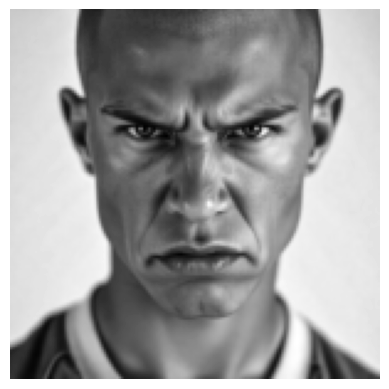

In [57]:
image_raw = imread(path + r'\AI-face-detection-Dataset\AI\35_20241130140313_A_close-up_shot_of_a_young_adult_male_person_of_Na.jpg')
image_width = 150

# Extract only the grayscale channel
image = rgb2gray(image_raw)

rescaled_image = rescale(image, image_width / image.shape[0], mode='reflect', anti_aliasing=True)

print(image_raw.shape)
print(rescaled_image.shape)
plt.figure()
plt.imshow(rescaled_image, cmap='gray')
plt.axis('off');

(150, 150, 2)
(150, 150)


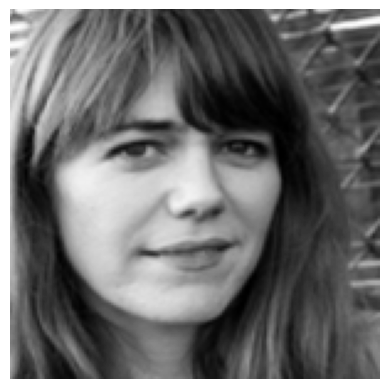

In [41]:
# Read the PNG file
image_raw = imread(path + r'\AI-face-detection-Dataset\real\non-child-1085.png')

# Extract only the grayscale channel
image = image_raw[..., 0]

# Resize the image to 150 x 150 pixels
image_width = 150
rescaled_image = rescale(image, image_width / image.shape[0], mode='reflect', anti_aliasing=True)

print(image_raw.shape)
print(image.shape)

# Display the image
plt.figure()
plt.imshow(rescaled_image, cmap='gray')
plt.axis('off')
plt.show()